In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sp

data = pd.read_csv("PS_2024.01.22_04.17.20.csv", skiprows = 100)


# Project description
Your job for this project is to approximate the detection for the radial velocity, transit, astrometry, and transit photometry techniques and plot them, as applicable, on mass vs period, mass vs semi-major axis, radius vs period, and radius vs semi-major axis plots and place the Solar System and the planets from project 1 in this context. You are welcome to use the M-a, M-P, R-a, R-p plots I have given you below.

### Main data products:
- Table with the astrometric, RV, direct imaging, and transit detection signals for all Solar System planets and HD 189733 b + GJ 1214 b
- Plots of mass vs period and mass vs semi-major axis with your astrometric and RV detection limits. 
- Plots of radius vs period and radius vs semi-major axis with your transit and direct imaging detection limits.
- Your plots should include all detected exoplanets color coded by the discovery technique, the Solar System planets, HD 189733 b, GJ 1214 b. You are welcome to steal my plots below for this part.


# Part 1: detection technique limitations
Below I have given you the fundamental equations for each technique you will need for this project. I have also listed some state-of-the-art instruments for each technique, but you are welcome to pick you own. **YOU ARE ONLT REQUIRED TO PICK ONE INSTRUMENT PER METHOD**. You will need to comb the literature to find the appropriate detection limits for whatever instruments you pick and estimate the detection limits based on the specifications of the instruement that you pick.

Once you have determined the detection limits for each technique, add them to the appropriate M-a, M-P, R-a, R-p plots (i.e., RV should go on the M-a and M-P plots, but does not need to go on the R-p and R-a plots). In your report, discuss what types of planets are observable by each detection method and why.

### Astrometry
$\LARGE \theta = \frac{M_p}{M_\star}\frac{a}{d}$

GRAVITY: https://www.eso.org/public/teles-instr/paranal-observatory/vlt/vlt-instr/gravity/

GAIA: https://sci.esa.int/web/gaia/-/31365-astrometry


### Radial Velocity
 $\LARGE K = \frac{M_p}{M_\star}\cdot\sqrt{\frac{GM_\star}{a}}\cdot\sin i$
 
 ESPRESSO: https://www.eso.org/sci/facilities/paranal/instruments/espresso.html
 
 EXPRES: https://lowell.edu/research/telescopes-and-facilities/ldt/extreme-precision-spectrometer-expres/
 
 HARPS: https://www.eso.org/public/teles-instr/lasilla/36/harps/
 
 PEPSI: https://pepsi.aip.de/
 
 KPF: https://www2.keck.hawaii.edu/inst/kpf/
 
 ### Direct imaging
Ignore reflected light and focus on the thermal emission contribution. Pick some logical values for $T_\star$ and $T_p$ and keep them fixed for your analysis.

 $\LARGE f = \left(\frac{R_p}{R_\star}\right)^2 \frac{\exp(h\nu / k_b T_\star) - 1}{\exp(h\nu / k_b T_p) - 1}$
 
 $\LARGE \theta_{min} = 1.22\frac{\lambda}{D}$
 
 Gemini Planet Imager: http://planetimager.org/
 
 SPHERE: https://www.eso.org/public/teles-instr/paranal-observatory/vlt/vlt-instr/sphere/

  
 
 ### Transit photometry
 
$\LARGE \delta = \left(\frac{R_p}{R_\star} \right)^2$

Kepler and K2: https://science.nasa.gov/mission/kepler/

TESS: https://tess.mit.edu/




## Example for Part 1: transit photometry

Say we consider a planet to be conclusively detected when it has a signal-to-noise ratio (SNR) of 3 or greater (the higher the SNR, the more confident we are that the signal is real). This means that the transit depth $\delta$ must be $\geq 3\times$ the noise floor of our detector (i.e., the uncertainty in each data point). The figure below illustrates this concept for $\delta = 0\times$noise (i.e., just the noise of our detector), $\delta = 1\times$noise (no detection), $\delta = 3\times$noise (minimum criteria for conclusive detection), $\delta = 5\times$noise (strong detection).

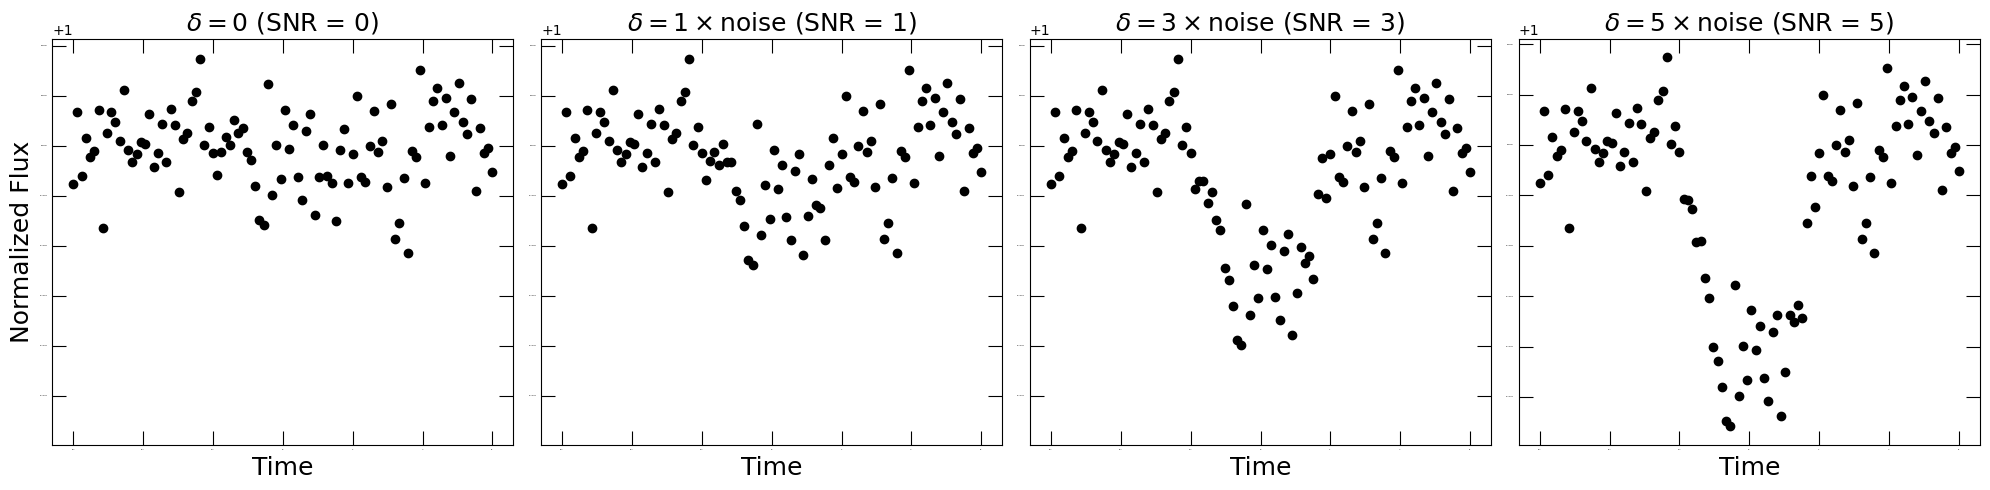

For this walkthrough, I'm going to adopt a noise of 20 ppm, meaning $\delta_{min} = 60$ ppm or $\delta_{min} = 60\times10^{-6}$ for a positive detection. You will need to research the state-of-the-art instruments to find your own value for the noise (and cite your source!), but it should be similar to the value I'm using.

Solving the $\delta$ equation for planet radius gives

$$\LARGE R_p = \sqrt{\delta}R_\star$$

subbing in $\delta_{min}$ gives the minimum detectable planet radius

$$\LARGE R_{p,min} = \sqrt{\delta_{min}}R_\star = \sqrt{60\times10^{-6}} R_\star \sim 0.008 R_\star$$

What should we use for $R_\star$? Up to you. I'm going to adopt $R_\star = 1 R_\odot$. I justify this choice by looking at the mean value of stellar radii for planets detected via the transit method which is close enough to 1$R_\odot$:

In [8]:
ind = np.where((data['discoverymethod'] == 'Transit') & (np.isnan(data['st_rad']) == False))

print('Mean R_star for planets discovered via transit photometry: ', np.mean(data['st_rad'].iloc[ind]))

Mean R_star for planets discovered via transit photometry:  1.0125236363636363


Now we can write

$$\LARGE R_{p,min} \sim 0.008\times R_\odot = 0.008\times 109 R_\oplus \sim 0.9R_\oplus$$

Next, most planets detected via the tansit photometry method came from the Kepler space telescope:

In [11]:
print('Frac of transiting planets detected by Kepler = ', str(round(len(np.where(data['disc_facility'] == 'Kepler')[0])/len(np.where(data['discoverymethod'] == 'Transit')[0]), 2)))

Frac of transiting planets detected by Kepler =  0.67


The primary mission of Kepler stared at the same field of view (i.e., the same patch of sky and the same sample of stars) for about 3 years. This means that the planets detected by Kepler would have been limited to orbital periods of $\lesssim 3$ years. Why? 

So, we have some approximate detection limits for transit photometry of $R_p \gtrsim 0.9 R_\oplus$ **AND** $P \lesssim 3$ years. Let's plot these limits and see how they compare to the data

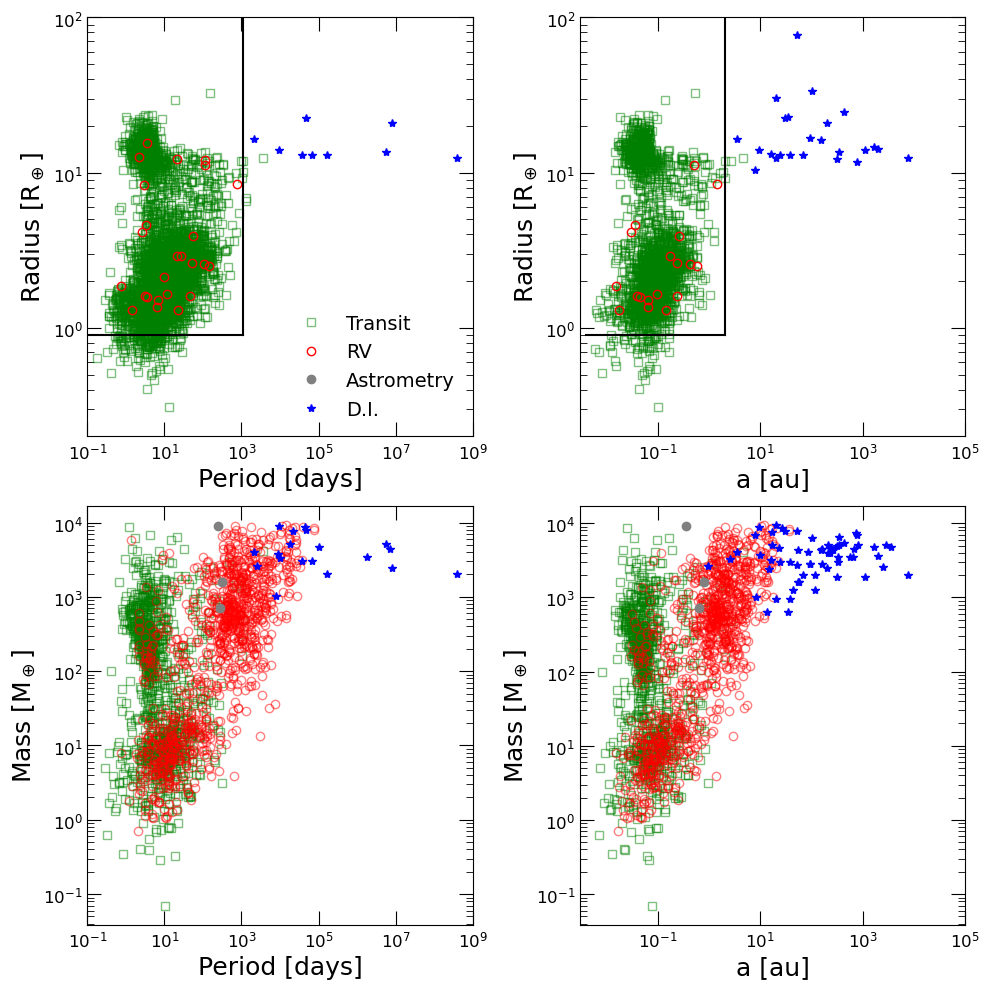

In [14]:
fig, ax = plt.subplots(2,2, figsize = (10,10))

ind_transit = np.where(data['discoverymethod'] == 'Transit')[0]
ind_rv = np.where(data['discoverymethod'] == 'Radial Velocity')[0]
ind_imaging = np.where(data['discoverymethod'] == 'Imaging')[0]
ind_astrometry = np.where(data['discoverymethod'] == 'Astrometry')[0]

ax[0,0].plot(data["pl_orbper"].iloc[ind_transit], data["pl_rade"].iloc[ind_transit], "gs", fillstyle = 'none', alpha = 0.5, label = 'Transit')
ax[0,0].plot(data["pl_orbper"].iloc[ind_rv], data["pl_rade"].iloc[ind_rv], "ro", fillstyle = 'none', alpha = 1.0, label = 'RV')
ax[0,0].plot(data["pl_orbper"].iloc[ind_astrometry], data["pl_rade"].iloc[ind_astrometry], "o", color = 'gray', alpha = 1.0, label = 'Astrometry')
ax[0,0].plot(data["pl_orbper"].iloc[ind_imaging], data["pl_rade"].iloc[ind_imaging], "b*", alpha = 1.0, label = 'D.I.')
ax[0,0].plot([min(data['pl_orbper']), 3.0*365], [0.9, 0.9], 'k-')
ax[0,0].plot([3.0*365, 3.0*365], [0.9, 100], 'k-')
ax[0,0].set_ylim(0.2, 100.0)
ax[0,0].set_xlim(0.1, 10**9)


ax[0,0].legend(fontsize = 14, frameon = False)

ax[0,0].set_xscale("log")
ax[0,0].set_yscale("log")
ax[0,0].set_xlabel("Period [days]", fontsize = 18)
ax[0,0].set_ylabel(r"Radius [R$_\oplus$]", fontsize = 18)



ax[0,1].plot(data["pl_orbsmax"].iloc[ind_transit], data["pl_rade"].iloc[ind_transit], "gs", fillstyle = 'none', alpha = 0.5)
ax[0,1].plot(data["pl_orbsmax"].iloc[ind_rv], data["pl_rade"].iloc[ind_rv], "ro", fillstyle = 'none', alpha = 1.0)
ax[0,1].plot(data["pl_orbsmax"].iloc[ind_astrometry], data["pl_rade"].iloc[ind_astrometry], "o", color = 'gray', alpha = 1.0)
ax[0,1].plot(data["pl_orbsmax"].iloc[ind_imaging], data["pl_rade"].iloc[ind_imaging], "b*", alpha = 1.0)


ax[0,1].plot([(min(data['pl_orbper'])/365)**(2.0/3.0), 3.0**(2.0/3.0)], [0.9, 0.9], 'k-')
ax[0,1].plot([3.0**(2.0/3.0), 3.0**(2.0/3.0)], [0.9, 100], 'k-')

ax[0,1].set_xscale("log")
ax[0,1].set_yscale("log")
ax[0,1].set_xlabel("a [au]", fontsize = 18)
ax[0,1].set_ylabel(r"Radius [R$_\oplus$]", fontsize = 18)
ax[0,1].set_ylim(0.2, 100.0)
ax[0,1].set_xlim(0.003, 10**5)



ax[1,0].plot(data["pl_orbper"].iloc[ind_transit], data["pl_bmasse"].iloc[ind_transit], "gs", fillstyle = 'none', alpha = 0.5)
ax[1,0].plot(data["pl_orbper"].iloc[ind_rv], data["pl_bmasse"].iloc[ind_rv], "ro", fillstyle = 'none', alpha = 0.5)
ax[1,0].plot(data["pl_orbper"].iloc[ind_astrometry], data["pl_bmasse"].iloc[ind_astrometry], "o", color = 'gray', alpha = 1.0)
ax[1,0].plot(data["pl_orbper"].iloc[ind_imaging], data["pl_bmasse"].iloc[ind_imaging], "b*", alpha = 1.0)

ax[1,0].set_xscale("log")
ax[1,0].set_yscale("log")
ax[1,0].set_xlabel("Period [days]", fontsize = 18)
ax[1,0].set_ylabel(r"Mass [M$_\oplus$]", fontsize = 18)
ax[1,0].set_xlim(0.1, 10**9)


ax[1,1].plot(data["pl_orbsmax"].iloc[ind_transit], data["pl_bmasse"].iloc[ind_transit], "gs", fillstyle = 'none', alpha = 0.5)
ax[1,1].plot(data["pl_orbsmax"].iloc[ind_rv], data["pl_bmasse"].iloc[ind_rv], "ro", fillstyle = 'none', alpha = 0.5)
ax[1,1].plot(data["pl_orbsmax"].iloc[ind_astrometry], data["pl_bmasse"].iloc[ind_astrometry], "o", color = 'gray', alpha = 1.0)
ax[1,1].plot(data["pl_orbsmax"].iloc[ind_imaging], data["pl_bmasse"].iloc[ind_imaging], "b*", alpha = 1.0)

ax[1,1].set_xscale("log")
ax[1,1].set_yscale("log")
ax[1,1].set_xlabel("a [au]", fontsize = 18)
ax[1,1].set_ylabel(r"Mass [M$_\oplus$]", fontsize = 18)
ax[1,1].set_xlim(0.003, 10**5)


ax[0,0].tick_params(which = 'major', top = True, right = True, labelsize = 12, length = 10, direction = 'in')
ax[0,0].tick_params(which = 'minor', top = True, right = True, labelsize = 12, length = 5, direction = 'in')

ax[0,1].tick_params(which = 'major', top = True, right = True, labelsize = 12, length = 10, direction = 'in')
ax[0,1].tick_params(which = 'minor', top = True, right = True, labelsize = 12, length = 5, direction = 'in')

ax[1,0].tick_params(which = 'major', top = True, right = True, labelsize = 12, length = 10, direction = 'in')
ax[1,0].tick_params(which = 'minor', top = True, right = True, labelsize = 12, length = 5, direction = 'in')

ax[1,1].tick_params(which = 'major', top = True, right = True, labelsize = 12, length = 10, direction = 'in')
ax[1,1].tick_params(which = 'minor', top = True, right = True, labelsize = 12, length = 5, direction = 'in')

plt.tight_layout()



### Not too bad!

# Part 2: placing the Solar System + Project 1 planets in context
Overlay the Solar System planets and HD 189733 b + GJ 1214 b on all plots. Calculate the signal for each planet for **EACH METHOD**. Put a table with these values in your report. Answer the following questions:
- Are any of them observable with any of the four techniques?
    - Which planets are observable with which techniques? Discuss why.
    - Which planets are unobservable with any of the techniques? Discuss why.
    
    
# Part 3
Part 1+2 will get you a maximum of 90% on the report. For the remaining 10%, I want you to pick one method to dig a bit deeper into. Below are some ideas to get you started, but as always, you are welcome to define your own problem.

### Transit photometry:
- Idea 1: Use the transit probability to estimate the actual number of planets as a function of orbital distance. Our sample of transiting planets is incomplete because of the transit probability: as semi-major axis increases the number of planets we detect decreases b/c they are less likely to transit. Plot a histogram of number of transiting planets as a function of orbital distance. Renomarlize this using the tranist probability and overlay the results on your histogram.
- Idea 2: the transit photometry example I gave above implicitly assumes that we only detect one transit per planet. Kepler stared at the same patch of sky for ~3 years meaning it would have detected ~1000 transits for planets with 1 day orbital periods, 100 for 10 day orbital periods, and so on. You can stack or average over multiple transits to get a higher signal to noise given. The signal to noise over multiple transits for Kepler is approximately (from https://iopscience.iop.org/article/10.1088/0067-0049/201/2/15/pdf)

$$\large SNR = \frac{\delta}{\sigma_{CDPP}} \sqrt{\frac{n_{tr} \cdot t_{dur}}{3 hr}}$$

Use this equation to derive a period-dependent transit photometry detection limit. $\sigma_{CDPP}$ is actually a star specific term. Just assume a optimistic single value of 30 ppm for it.

### Direct imaging:
- idea 1: Look up how to calculate the equilibrium temperature of a planet as a function of its orbital distance. Use this to investigate how the minimum detectable planet radius changes as a function of semi-major axis for direct imaging.
- idea 2: Repeat part 1 but for reflected light. Add this to your plots and discuss the difference in the detection limits between reflected and thermally emitted light.

### For any of the techniques:
- idea 1: Pick on parameter that you assumed a fixed value for (like $R_\star$, $M_\star$, $T_\star$, $d$) and use the NASA exoplanet archive to determine a range of likely values and calculate a detection limit range and add it to your plots. For example, for the radial velocity method, you could vary $M_\star$.
- idea 2: Repeat part 1 for a relatively new mission (like TESS for transit photometry). Plot it and discuss what information you expect it to add to our understanding of exoplanet demographics.




## Something that may make your life a bit easier
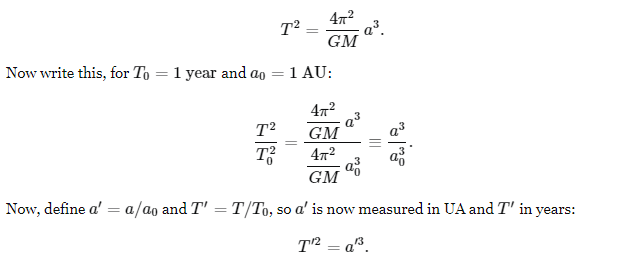